# Tutorial: Influence Diagrams (ID / LIMID) in aGrUM (C++)

Ported from the [pyAgrum notebook](../../wrappers/pyagrum/doc/sphinx/notebooks/21-Models_InfluenceDiagram.ipynb). Same caveat as the other C++ tutorials here: each `%%cpp` cell is a standalone program, no state shared with the previous cell.

In [1]:
%load_ext gum_cppnb

## Building an influence diagram

`fastPrototype` uses the same mini-language as `fastID` in Python: plain name = chance node, `*name` = decision node, `$name` = utility node.

Influence Diagram{
  chance: 3,
  utility: 1,
  decision: 4,
  arcs: 8,
  domainSize: 128
}


[0]

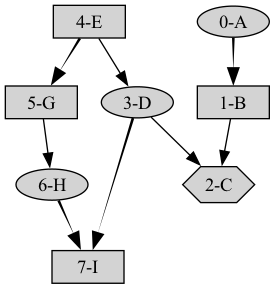

In [2]:
%%cpp
#include <agrum/id.h>

int main() {
  auto diag = gum::InfluenceDiagram<double>::fastPrototype("A->*B->$C<-D<-*E->*G->H->*I<-D");
  std::cout << diag.toString() << std::endl;
  cppnb_add_dot(diag.toDot());
}

### The hard way

Chance/decision/utility nodes each have their own `add*Node` method. `cpt(...)` (chance nodes) and `utility(...)` (utility nodes) both return a `Tensor<GUM_SCALAR>&`, filled exactly like a BayesNet CPT.

optimal decision for d:

  d                │
0        │1        │
─────────│─────────│
 0.0000  │ 1.0000  │

MEU: 110.5 +- 8010.25


[0]

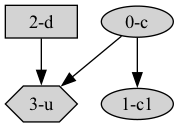

In [3]:
%%cpp
#include <agrum/id.h>

int main() {
  gum::InfluenceDiagram<double> net;
  auto c  = net.add(gum::LabelizedVariable("c", "chance variable", 2));
  auto c1 = net.add(gum::LabelizedVariable("c1", "chance variable 1", 2));
  auto d  = net.addDecisionNode(gum::LabelizedVariable("d", "decision variable", 2));
  auto u  = net.addUtilityNode(gum::LabelizedVariable("u", "utility", 1));

  net.addArc(c, u);
  net.addArc(c, c1);
  net.addArc(d, u);

  net.cpt(c).fillWith({0.5, 0.5});
  net.cpt(c1).fillWith({1, 0, 0, 1});
  net.utility(u).fillWith({10, 100, 21, 200});
  cppnb_add_dot(net.toDot());

  gum::ShaferShenoyLIMIDInference inf(&net);
  inf.makeInference();
  std::cout << "optimal decision for d:\n" << inf.optimalDecision(d) << std::endl;
  std::cout << "MEU: " << inf.MEU().first << " +- " << inf.MEU().second << std::endl;
}

## Evidence in an influence diagram

Same `addEvidence`/`makeInference` idiom as `LazyPropagation`/`ShaferShenoyMRFInference` -- observing the chance node changes the optimal decision computed on the utility node.

In [4]:
%%cpp
#include <agrum/id.h>

int main() {
  gum::InfluenceDiagram<double> net;
  auto c = net.add(gum::LabelizedVariable("c", "chance variable", 2));
  auto d = net.addDecisionNode(gum::LabelizedVariable("d", "decision variable", 2));
  auto u = net.addUtilityNode(gum::LabelizedVariable("u", "utility", 1));
  net.addArc(c, u);
  net.addArc(d, u);
  net.cpt(c).fillWith({0.5, 0.5});
  net.utility(u).fillWith({10, 100, 21, 200});

  gum::ShaferShenoyLIMIDInference inf(&net);
  inf.addEvidence(c, 0);
  inf.makeInference();
  std::cout << "optimal decision knowing c=0:\n" << inf.optimalDecision(d) << std::endl;
}

optimal decision knowing c=0:

  d                │
0        │1        │
─────────│─────────│
 0.0000  │ 1.0000  │



## LIMID versus influence diagram: the no-forgetting assumption

With several decision nodes, `ShaferShenoyLIMIDInference` needs a declared decision order before it can solve the diagram -- without it, `makeInference()` throws (`gum::FatalError`, "not solvable"). `addNoForgettingAssumption` declares that order; after that, `reducedLIMID()`/`junctionTree()` expose the solved structure.

In [5]:
%%cpp
#include <agrum/id.h>

int main() {
  auto diag = gum::InfluenceDiagram<double>::fastPrototype(
      "Chance->*Decision1->Chance2->$Utility<-Chance3<-*Decision2<-Chance->Utility");
  std::cout << diag.toString() << std::endl;

  gum::ShaferShenoyLIMIDInference ie(&diag);
  try {
    ie.makeInference();
    std::cout << "solved without no-forgetting assumption" << std::endl;
  } catch (gum::Exception& e) {
    std::cout << "error without no-forgetting: " << e.errorType() << std::endl;
  }

  ie.addNoForgettingAssumption(std::vector<std::string>{"Decision1", "Decision2"});
  ie.makeInference();
  std::cout << "solved after addNoForgettingAssumption" << std::endl;
  std::cout << "reducedLIMID: " << ie.reducedLIMID().toString() << std::endl;
  std::cout << "junctionTree size: " << ie.junctionTree()->size() << std::endl;
}

Influence Diagram{
  chance: 3,
  utility: 1,
  decision: 2,
  arcs: 7,
  domainSize: 32
}
error without no-forgetting: Fatal error
solved after addNoForgettingAssumption
reducedLIMID: Influence Diagram{
  chance: 3,
  utility: 1,
  decision: 2,
  arcs: 8,
  domainSize: 32
}
junctionTree size: 2


## Input/output

Same jgum JSON format and `GumIDWriter`/`GumIDReader` classes as `GumBNWriter`/`GumBNReader` for BayesNet (see the aGrUM C++ tutorial notebook), written to the git-ignored `out/` folder.

In [6]:
%%cpp
#include <agrum/id.h>
#include <agrum/ID/io/GUM/GumIDWriter.h>
#include <agrum/ID/io/GUM/GumIDReader.h>
#include <filesystem>

int main() {
  std::filesystem::create_directories("out");

  gum::InfluenceDiagram<double> net;
  auto c = net.add(gum::LabelizedVariable("c", "chance variable", 2));
  auto d = net.addDecisionNode(gum::LabelizedVariable("d", "decision variable", 2));
  auto u = net.addUtilityNode(gum::LabelizedVariable("u", "utility", 1));
  net.addArc(c, u);
  net.addArc(d, u);
  net.cpt(c).fillWith({0.5, 0.5});
  net.utility(u).fillWith({10, 100, 21, 200});

  gum::GumIDWriter<double> writer(false, 2);
  writer.write("out/small_id.gum", net);

  gum::InfluenceDiagram<double> net2;
  gum::GumIDReader<double> reader(&net2, "out/small_id.gum");
  std::cout << "read back, errors: " << reader.proceed() << std::endl;

  gum::ShaferShenoyLIMIDInference ie1(&net);
  ie1.makeInference();
  gum::ShaferShenoyLIMIDInference ie2(&net2);
  ie2.makeInference();
  std::cout << "optimalDecision original:  " << ie1.optimalDecision(d) << std::endl;
  std::cout << "optimalDecision round-trip:" << ie2.optimalDecision("d") << std::endl;
}

read back, errors: 0
optimalDecision original:  
  d                │
0        │1        │
─────────│─────────│
 0.0000  │ 1.0000  │

optimalDecision round-trip:
  d                │
0        │1        │
─────────│─────────│
 0.0000  │ 1.0000  │

